In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io import arff
import ruptures as rpt
from ruptures.base import BaseCost
import time
import pyreadr

from rfpop import rfpop, get_breakpoints
from piecewise import L2Loss, L1Loss, Huber, BiWeight, PiecewiseQuadratic

In [3]:
def compare_losses(y, K, beta, scatter=True):

    _, ax = plt.subplots(2, 2, figsize=(25, 15))

    loss = BiWeight(0, K, 0, 0)
    cp = rfpop(y, loss, beta, verbose=False)
    taus = [elt[1] for elt in cp]
    bkpts = get_breakpoints(taus)
    if scatter:
        ax[0,0].scatter(np.arange(len(y)), y)
    else:
        ax[0,0].plot(np.arange(len(y)), y)
    for b in bkpts:
        ax[0,0].axvline(x=b+0.5, color='r')
        
    loss = Huber(0, K, 0, 0)
    cp = rfpop(y, loss, beta, verbose=False)
    taus = [elt[1] for elt in cp]
    bkpts = get_breakpoints(taus)
    if scatter:
        ax[0,1].scatter(np.arange(len(y)), y)
    else:
        ax[0,1].plot(np.arange(len(y)), y)
    for b in bkpts:
        ax[0,1].axvline(x=b+0.5, color='r')

    loss = L2Loss(0, 0, 0)
    time_start = time.time()
    cp = rfpop(y, loss, beta, verbose=False)
    print("L2: ", time.time() - time_start)
    taus = [elt[1] for elt in cp]
    bkpts = get_breakpoints(taus)
    if scatter:
        ax[1,0].scatter(np.arange(len(y)), y)
    else:
        ax[1,0].plot(np.arange(len(y)), y)
    for b in bkpts:
        ax[1,0].axvline(x=b+0.5, color='r')

    loss = L1Loss(0, 0, 0)
    time_start = time.time()
    cp = rfpop(y, loss, beta, verbose=False)
    print("L1: ", time.time() - time_start)
    taus = [elt[1] for elt in cp]
    bkpts = get_breakpoints(taus)
    if scatter:
        ax[1,1].scatter(np.arange(len(y)), y)
    else:
        ax[1,1].plot(np.arange(len(y)), y)
    for b in bkpts:
        ax[1,1].axvline(x=b+0.5, color='r')
        
    plt.show()

## EthanolConcentration (site de Laulau)

In [2]:
path = "C:\Jeremie\MVA\Machine learning for time series\EthanolConcentration\LOBOFolds\EthanolConcentration0_TRAIN.arff"

In [3]:
arff_file = arff.loadarff(path)
df = pd.DataFrame(arff_file[0])

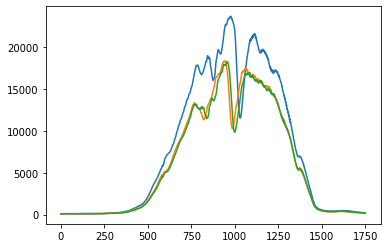

In [4]:
plt.plot(list(df["relationalAtt"][0][0]))
plt.plot(list(df["relationalAtt"][0][1]))
plt.plot(list(df["relationalAtt"][0][2]))

In [5]:
y = np.array(list(df["relationalAtt"][0][0]))
y /= np.max(y)

100%|██████████| 1751/1751 [00:47<00:00, 37.01it/s]


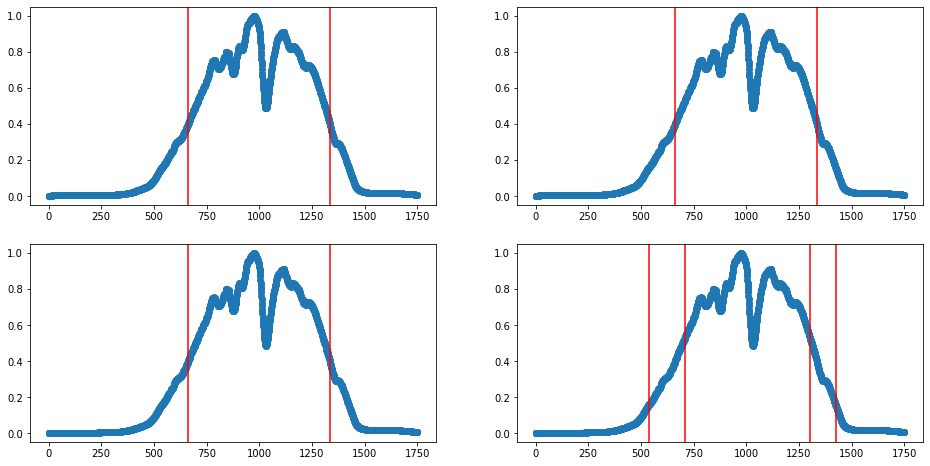

In [14]:
compare_losses(y, 0.5, 10)

## Household Electric Power Consumption (Kaggle)

In [17]:
path = "C:\Jeremie\MVA\Machine learning for time series\household_electric_power_consumption.txt"
df = pd.read_csv(path, sep=";", header=0)
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S")
for col in ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

C:\Users\jerem\AppData\Local\Temp\ipykernel_24140\2403169264.py:2: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=";", header=0)


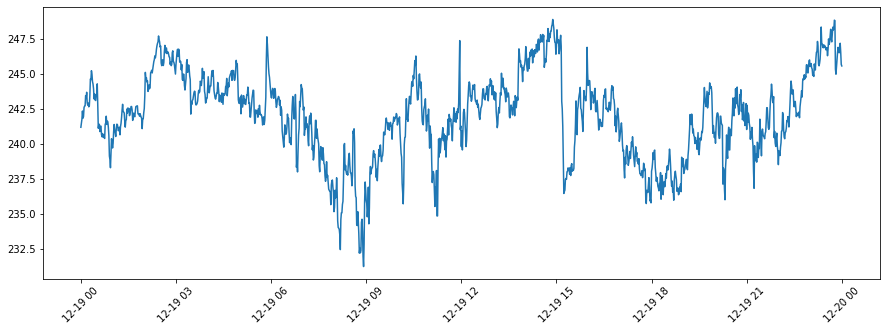

In [18]:
sub_df = df[(df["Datetime"] >= "2006-12-19") & (df["Datetime"] <= "2006-12-20")]
plt.figure(figsize=(15, 5))
plt.plot(sub_df["Datetime"], sub_df["Voltage"])
plt.xticks(rotation=45)
plt.show()

## Hole Deviation EDA (Kaggle)

In [103]:
path = "C:\Jeremie\MVA\Machine learning for time series\well_log.csv"
df = pd.read_csv(path, index_col=0)

In [106]:
df

,Depth,Gamma-ray,Shale_Volume,Restivity,Delta T,Vp,Vs,Density,Density_Calculated,Neuron_Porosity,Density_Porosity,Possions_Ratio,Classification
0,4000,73.215,0.7965,0.25,137.81,7256.3675,2799.0030,2.1278,2.1278,-999.25,0.2818,0.4126,0
1,4001,69.152,0.7391,0.20,138.06,7243.2276,2804.5841,2.1202,2.1202,-999.25,0.2893,0.4118,0
2,4002,65.965,0.6940,0.21,138.06,7243.2276,2817.0360,2.1149,2.1149,-999.25,0.2946,0.4109,0
3,4003,68.215,0.7258,0.27,137.31,7282.7908,2839.0723,2.1217,2.1217,-999.25,0.2889,0.4104,0
4,4004,70.840,0.7630,0.36,136.31,7336.2189,2870.3577,2.1301,2.1301,-999.25,0.2819,0.4096,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,4296,55.637,0.5337,0.27,136.06,7349.6987,2945.4264,2.1044,2.1044,-999.25,0.3083,0.4043,0
297,4297,61.012,0.6164,0.34,130.81,7644.6755,3152.9818,2.1361,2.1361,-999.25,0.2847,0.3975,0
298,4298,40.105,0.2945,0.49,117.53,8508.4659,3934.4175,2.1579,2.1579,-999.25,0.2855,0.3640,1
299,4299,28.286,0.1124,0.65,110.53,9047.3175,4426.3291,2.1702,2.1702,-999.25,0.2859,0.3427,1


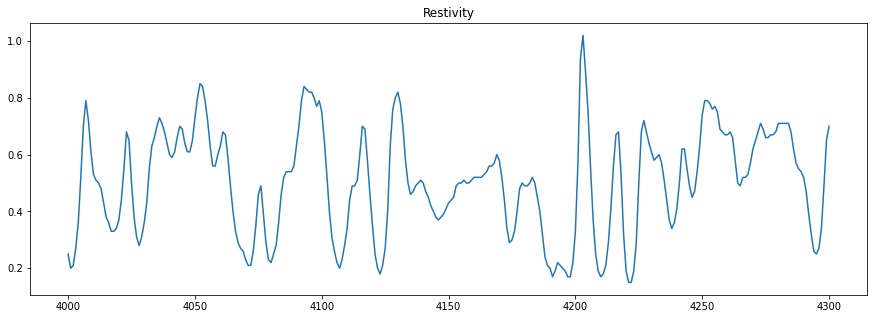

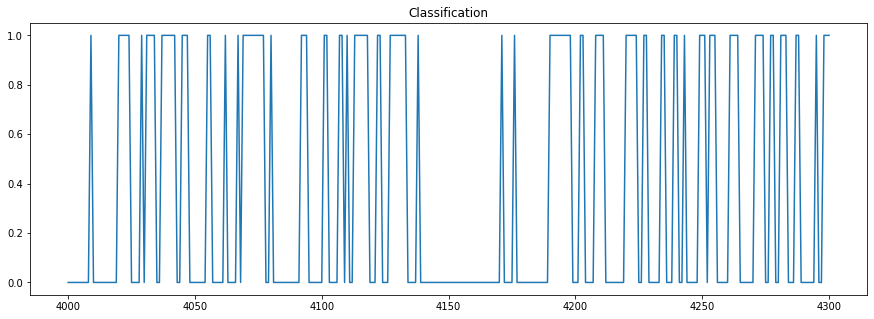

In [111]:
for col in ["Restivity", "Classification"]: # df.columns:
    plt.figure(figsize=(15, 5))
    plt.plot(df["Depth"], df[col])
    plt.title(col)
    plt.show()

## US Monthly Unemployment Rate 1948 - Present (Kaggle)

In [4]:
path = "C:\\Jeremie\\MVA\\Machine learning for time series\\USUnemployment.csv"
with open(path, "r") as f:
    lines = f.readlines()

t = []
y = []
for line in lines[1:]:
    line = line.strip().split(",")
    t.append(line[0])
    for elt in line[1:]:
        if elt != "":
            y.append(float(elt))

new_t = []
for year in t:
    for month in range(1, 13):
        new_t.append(f"{year}-{month:02d}")

new_t = pd.to_datetime(new_t)

100%|██████████| 864/864 [00:00<00:00, 1281.88it/s]


L2:  0.6779880523681641


100%|██████████| 864/864 [00:01<00:00, 727.68it/s]


L1:  1.1903514862060547


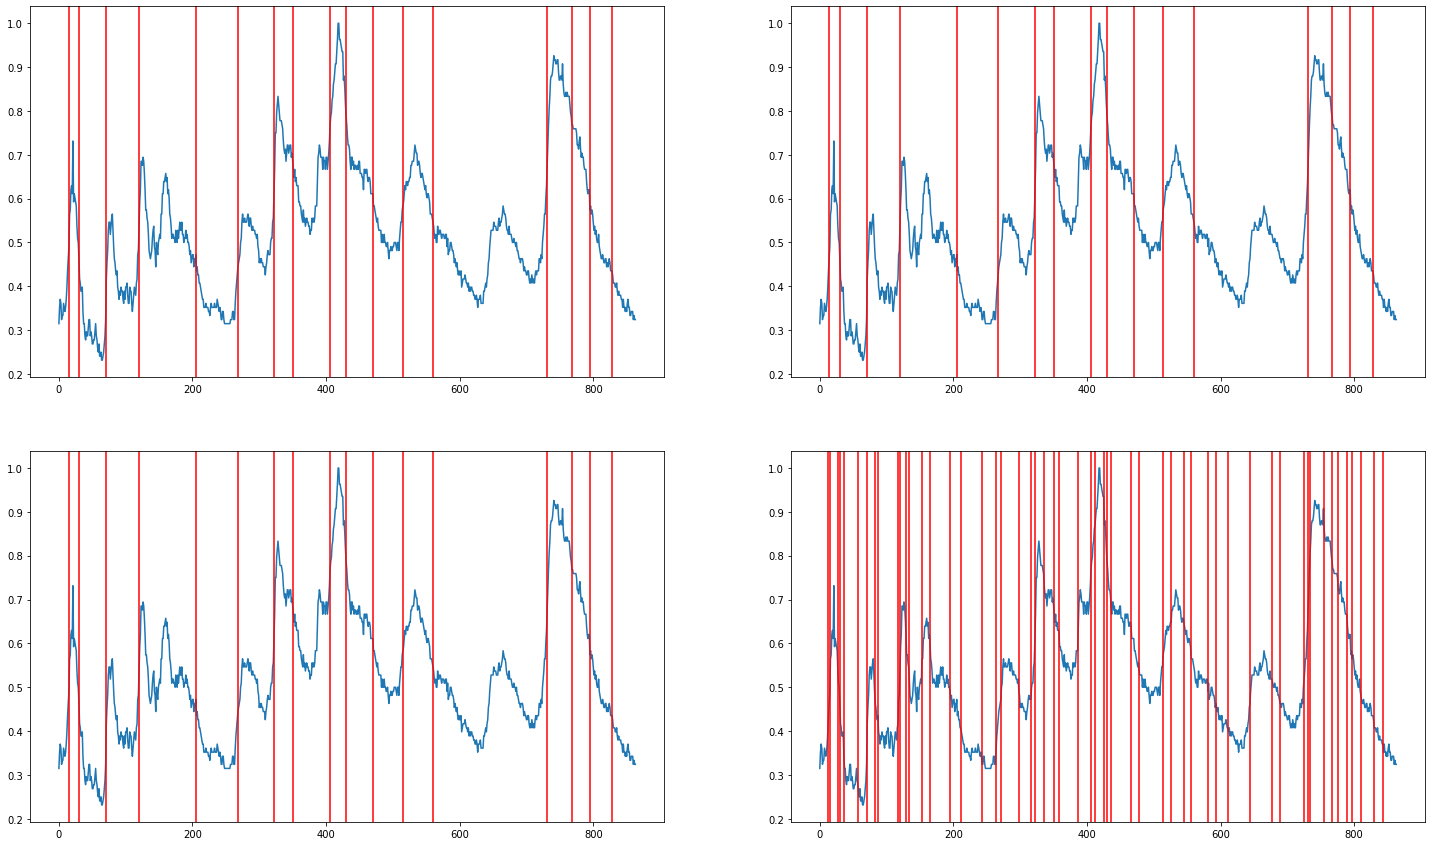

In [5]:
y = np.array(y)
y /= np.max(y)
compare_losses(y, 2.5, 0.2, scatter=False)

L2:  1.5011122226715088
L1:  0.8008072376251221


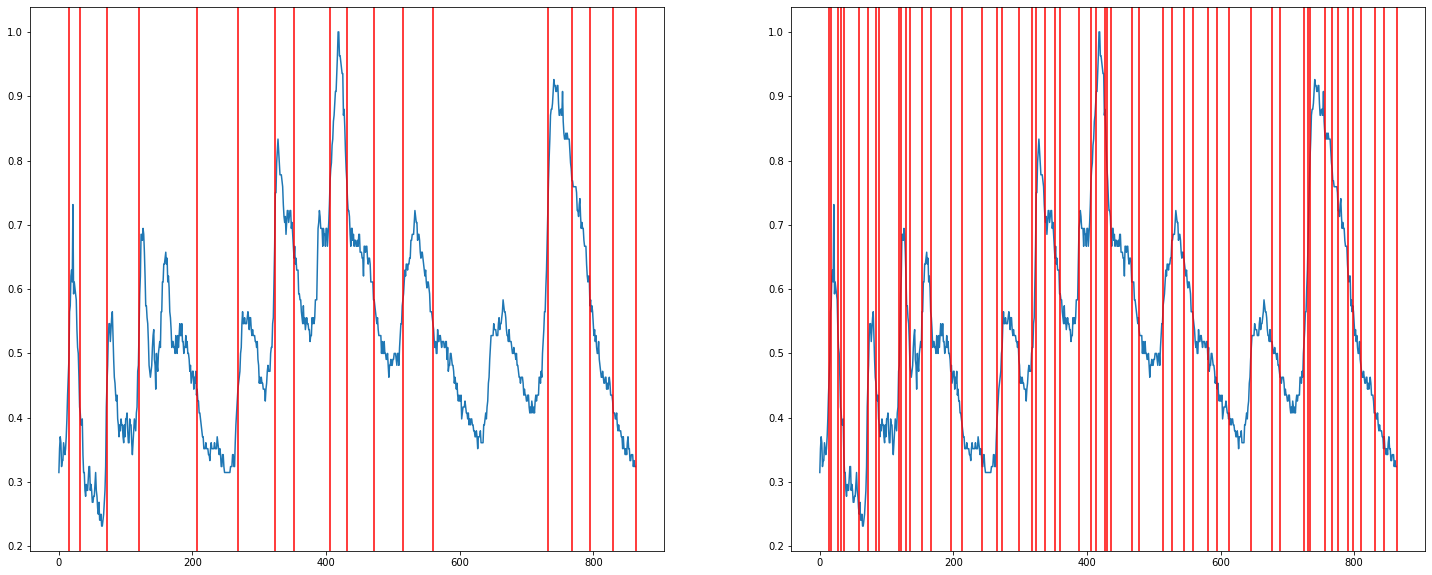

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(25, 10))

time_start = time.time()
predicted_bkps = rpt.Pelt(model="l2", jump=1).fit_predict(signal=y, pen=0.2)
print("L2: ", time.time() - time_start)
ax[0].plot(y)
for b in predicted_bkps:
    ax[0].axvline(x=b+0.5, color='r')

time_start = time.time()
predicted_bkps = rpt.Pelt(model="l1", jump=1).fit_predict(signal=y, pen=0.2)
print("L1: ", time.time() - time_start)
ax[1].plot(y)
for b in predicted_bkps:
    ax[1].axvline(x=b+0.5, color='r')
    
plt.show()

In [ ]:
class BiweightCost(BaseCost):

    """Custom cost for piecewise Poisson signals."""

    # The 2 following attributes must be specified for compatibility.
    model = "Biweight"
    min_size = 2

    def fit(self, signal):
        """Set the internal parameter."""
        self.signal = signal
        return self

    def error(self, start, end):
        """Return the approximation cost on the segment [start:end].

        Args:
            start (int): start of the segment
            end (int): end of the segment

        Returns:
            float: segment cost
        """
        sub = self.signal[start:end]
        m = sub.mean()
        val = -(end-start)*m*np.log(m)
        return val

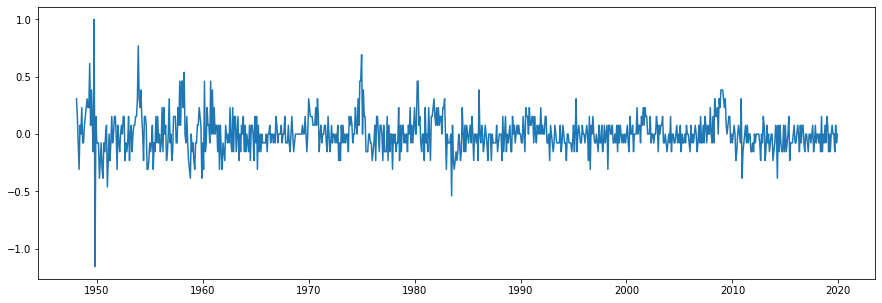

100%|██████████| 863/863 [00:00<00:00, 957.93it/s] 


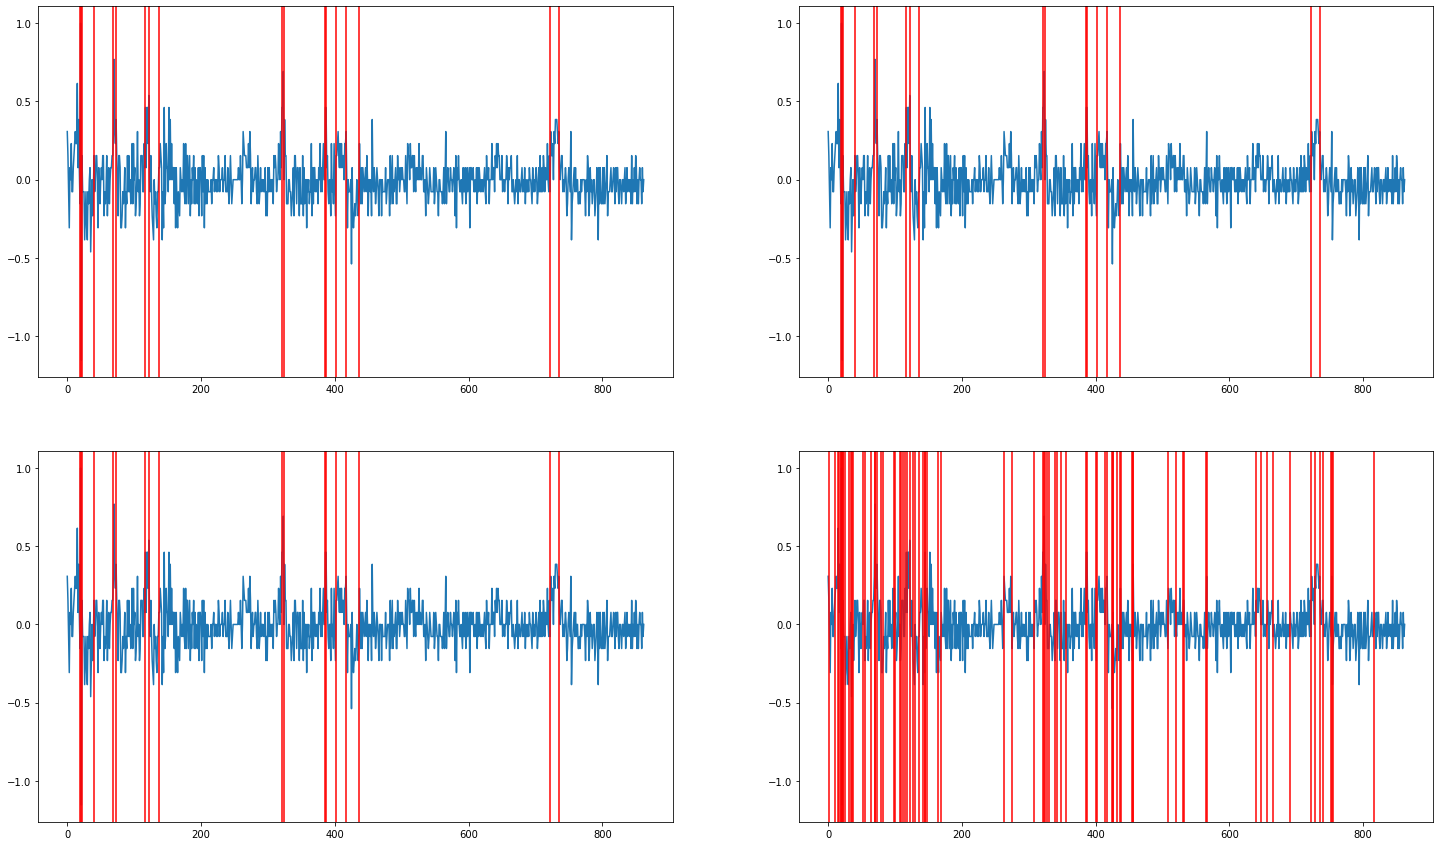

In [28]:
y_deriv = [(y[i+1] - y[i]) for i in range(len(y)-1)]
y_deriv = np.array(y_deriv)
y_deriv /= np.max(y_deriv)
plt.figure(figsize=(15, 5))
plt.plot(new_t[1:], y_deriv)
plt.show()

compare_losses(y_deriv, 2.5, 0.2, scatter=False)

## Ice core DML94C07_38 (Kaggle)

In [162]:
path = "C:\Jeremie\MVA\Machine learning for time series\DML94C07_38_monthly_Ca_NO3_dust.txt"

In [163]:
df = pd.read_csv(path, sep="\t", header=0)

In [165]:
# Convert to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [166]:
df

,Depth ice/snow [m],Age [ka BP],Age [a AD],Depth bot [m],Depth top [m],Ca2+ [ng/g],Dust [#/ml],[NO3]- [ng/g]
0,6.03,-0.054417,2004.4167,6.062,6.000,18.4,1077,18.0
1,6.11,-0.054333,2004.3333,6.160,6.062,13.5,443,20.7
2,6.21,-0.054250,2004.2500,6.255,6.160,14.4,235,17.9
3,6.30,-0.054167,2004.1667,6.349,6.255,13.8,113,7.7
4,6.39,-0.054083,2004.0833,6.441,6.349,9.9,112,23.9
...,...,...,...,...,...,...,...,...
504,79.58,-0.012417,1962.4167,79.628,79.523,7.3,54,10.8
505,79.68,-0.012333,1962.3333,79.731,79.628,7.8,48,8.9
506,79.78,-0.012250,1962.2500,79.833,79.731,8.0,56,11.4
507,79.88,-0.012167,1962.1667,79.934,79.833,9.0,69,15.1


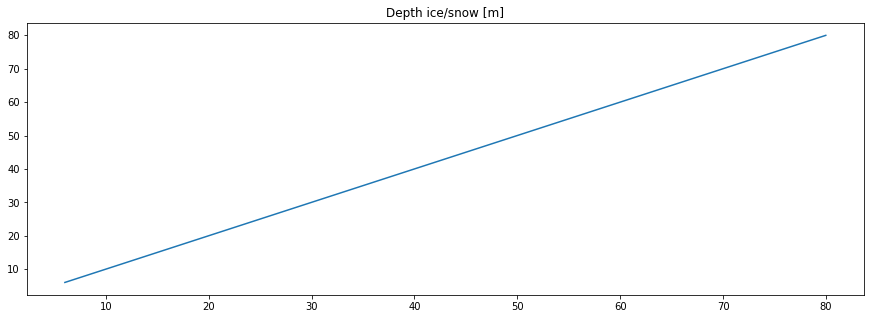

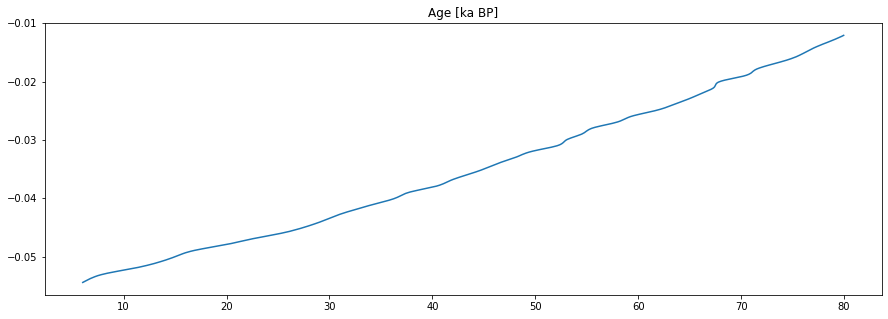

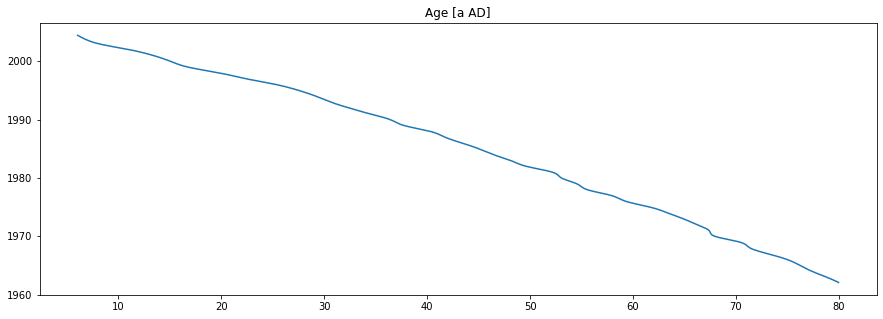

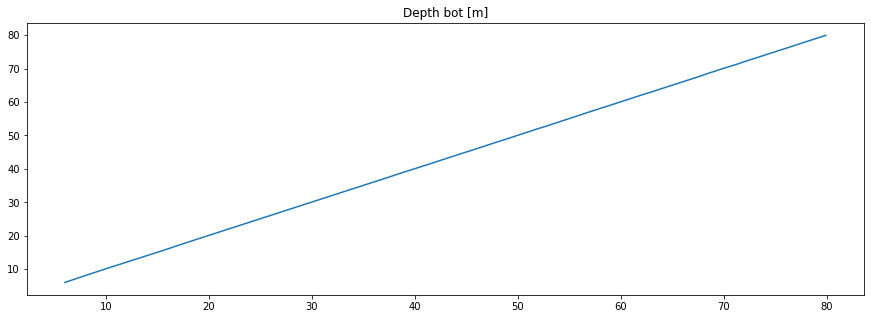

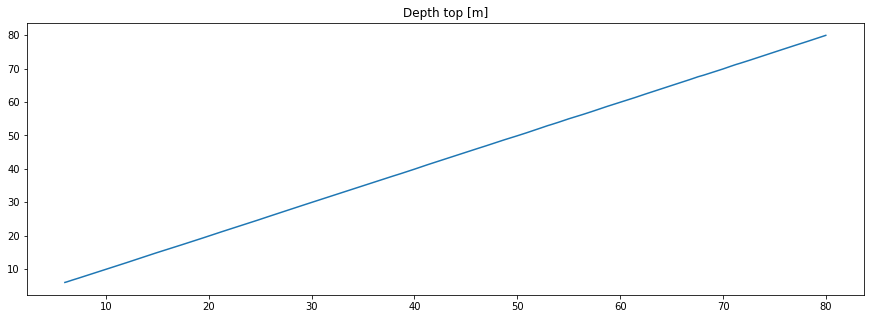

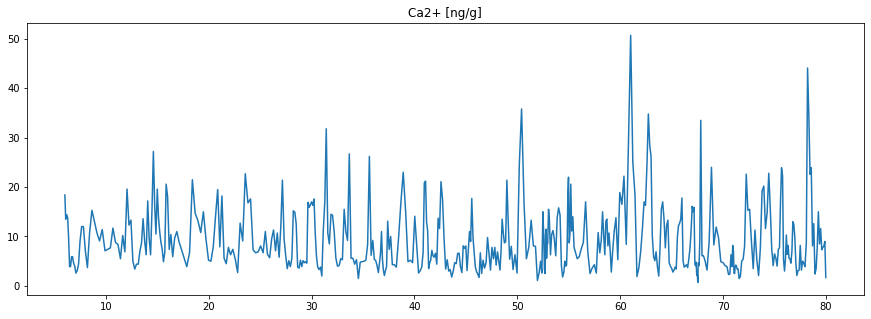

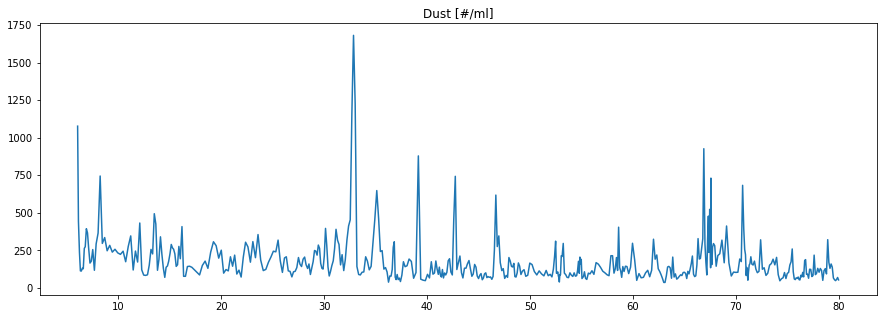

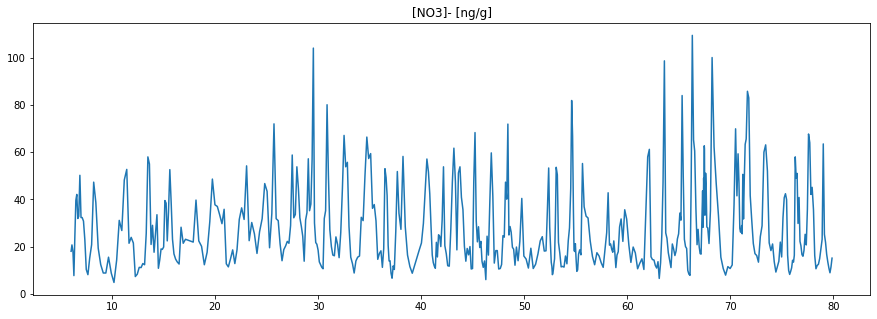

In [167]:
for col in df.columns:
    plt.figure(figsize=(15, 5))
    plt.plot(df["Depth ice/snow [m]"], df[col])
    plt.title(col)
    plt.show()

## French bakery daily sales

In [168]:
path = "C:\Jeremie\MVA\Bakery sales.csv"

In [181]:
df = pd.read_csv(path, header=0, index_col=0)

In [183]:
# Group by date and sum for BAGUETTE
baguette = df[df["article"] == "BAGUETTE"]
df = df.groupby("date").sum().reset_index()[["date", "Quantity"]]

In [188]:
df

,date,Quantity
0,2021-01-02,581.0
1,2021-01-03,564.0
2,2021-01-04,315.0
3,2021-01-05,309.0
4,2021-01-07,310.0
...,...,...
595,2022-09-26,399.0
596,2022-09-27,423.0
597,2022-09-28,357.0
598,2022-09-29,428.0


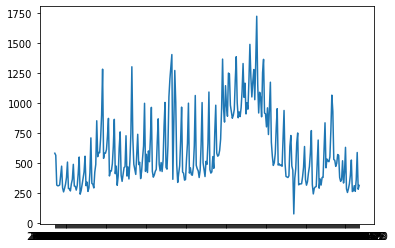

In [190]:
sub_df = df[(df["date"] >= "2021-01") & (df["date"] <= "2021-12")]
plt.plot(sub_df["date"], sub_df["Quantity"])

100%|██████████| 313/313 [00:00<00:00, 2045.52it/s]


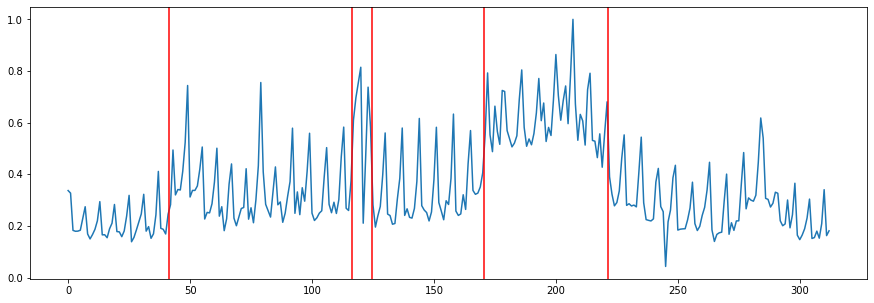

In [192]:
y = np.array(sub_df["Quantity"])
y /= np.max(y)

cp = rfpop(y, 2.5, 0.2, verbose=False)
taus = [elt[1] for elt in cp]

plt.figure(figsize=(15, 5))
bkpts = get_breakpoints(taus)
plt.plot(np.arange(len(y)), y)
for b in bkpts:
    plt.axvline(x=b+0.5, color='r')
plt.show()

## S&P 500 stock data (Kaggle)

In [198]:
path_zion = "C:\Jeremie\MVA\Machine learning for time series\ZION_data.csv"
path_aapl = "C:\Jeremie\MVA\Machine learning for time series\AAPL_data.csv"

In [199]:
df_zion = pd.read_csv(path_zion, header=0)
df_aapl = pd.read_csv(path_aapl, header=0)

In [202]:
y = np.array(df_aapl["open"])
y_deriv = [(y[i+1] - y[i]) for i in range(len(y)-1)]

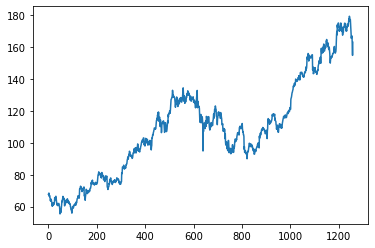

In [205]:
plt.plot(y)

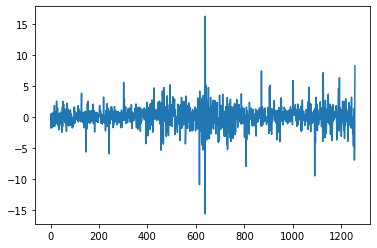

In [204]:
plt.plot(y_deriv)

## Neuroblastoma 575 benchmark

In [3]:
# Path to your .RData file
file_path = "C:/Jeremie/MVA/Machine learning for time series/neuroblastoma_2023.9.3/neuroblastoma/data/neuroblastoma.RData"

# Read the .RData file
result = pyreadr.read_r(file_path)

# Display the keys (names of objects in the .RData file)
print(result.keys())

# Access objects from the file
for key, value in result.items():
    print(f"Object name: {key}")
    print(f"Content: {value}")


odict_keys([])


In [4]:
result

OrderedDict()

In [12]:
import rpy2.robjects as robjects
from rpy2.robjects import r
from rpy2.robjects import globalenv

# Path to your .RData file
file_path = "path/to/your/file.RData"

# Load the .RData file into R environment
r.load(file_path)

# Extract variables from the R environment
for var in globalenv.keys():
    print(f"Variable name: {var}")
    print(f"Content: {globalenv[var]}")

ModuleNotFoundError: No module named 'rpy2'